In [1]:
from typing import Callable

import warnings
warnings.filterwarnings('ignore')

import re
import pandas as pd
import numpy as np

from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.rcParams["figure.autolayout"] = True

from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

import seaborn as sns

from src import Policy_Value_Net, Rand_Player, Flat_Player, Deep_Player

In [2]:
def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

In [3]:
SMALL_GAME = (6, 6, 4)
MEDIUM_GAME = (8, 8, 5)

small_net = Policy_Value_Net(
    game_kwargs=SMALL_GAME, 
    model_file=f"_zero/models/best_{SMALL_GAME[0]}_{SMALL_GAME[1]}_{SMALL_GAME[2]}.model",
)

medium_net = Policy_Value_Net(
    game_kwargs=MEDIUM_GAME, 
    model_file=f"_zero/models/best_{MEDIUM_GAME[0]}_{MEDIUM_GAME[1]}_{MEDIUM_GAME[2]}.model",
)

all_players = [
    ("Rand", Rand_Player(), .0),
    ("Flat", Flat_Player(policy_value_fn=medium_net.policy_value_fn_sorted), .0),
    ("Zero", Deep_Player(iterations=600, policy_value_fn=medium_net.policy_value_fn_sorted), .0),
    ("UCT1", Deep_Player(iterations=1000), .0),
    ("UCT3", Deep_Player(iterations=3000), .0),
    ("UCT6", Deep_Player(iterations=6000), .0),
]

In [4]:
train_keys = {
    "kl": float,
    "lrMultiplier": float,
    "loss": float,
    "entropy": float,
    "explVarOld": float,
    "explVarNew": float,
}

eval_keys = {
    "numPlayouts": int,
    "win": int,
    "lose": int,
    "tie": int,
    "avgCurrStarted": float,
}

In [5]:
train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open("_zero/logs/losses.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

train_df_with_na = train_df.copy(deep=True)

train_df_with_na["explVarOld"] = train_df_with_na["explVarOld"].map(lambda x: x if x > -np.infty else np.nan)
train_df_with_na["explVarNew"] = train_df_with_na["explVarNew"].map(lambda x: x if x > -np.infty else np.nan)

train_df = train_df_with_na.dropna()

In [6]:
train_df.describe()

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
count,2862,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000
mean,2024-01-20 17:11:14.856756480,0.050721,0.198921,1.972805,1.413352,0.320131,0.365286
min,2024-01-18 11:55:00.877000,0.009910,0.198000,1.312550,0.750280,-0.280000,-0.136000
25%,2024-01-19 12:24:01.640250112,0.034357,0.198000,1.727218,1.166225,0.213000,0.239000
50%,2024-01-21 12:03:32.782500096,0.044535,0.198000,1.891965,1.378785,0.322000,0.373000
75%,2024-01-21 21:18:23.765750016,0.059980,0.198000,2.085285,1.549148,0.438750,0.506000
max,2024-01-22 06:48:46.946000,1.349690,0.667000,5.408990,4.131410,0.683000,0.733000
std,NaN,0.039051,0.017608,0.454983,0.396029,0.146260,0.164657


In [7]:
train_df.corr().style.background_gradient("hot")

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
timestamp,1.000000,-0.223673,-0.015438,-0.294359,-0.005999,0.818024,0.860035
kl,-0.223673,1.000000,0.620792,0.224697,-0.022991,-0.262248,-0.249768
lrMultiplier,-0.015438,0.620792,1.000000,0.328835,0.139533,-0.153111,-0.128485
loss,-0.294359,0.224697,0.328835,1.000000,0.900216,-0.462050,-0.450109
entropy,-0.005999,-0.022991,0.139533,0.900216,1.000000,-0.117049,-0.108359
explVarOld,0.818024,-0.262248,-0.153111,-0.462050,-0.117049,1.000000,0.992302
explVarNew,0.860035,-0.249768,-0.128485,-0.450109,-0.108359,0.992302,1.000000


In [8]:
eval_df.describe()

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
count,57,57.000000,57.000000,57.000000,57.000000,57.000000
mean,2024-01-20 17:49:51.618859520,1842.105263,3.982456,5.929825,0.087719,0.508772
min,2024-01-18 12:43:58.232000,1500.000000,0.000000,0.000000,0.000000,0.200000
25%,2024-01-19 14:14:23.910000128,1500.000000,1.000000,3.000000,0.000000,0.400000
50%,2024-01-21 12:27:05.100999936,1500.000000,4.000000,6.000000,0.000000,0.500000
75%,2024-01-21 21:34:09.660999936,1500.000000,6.000000,8.000000,0.000000,0.600000
max,2024-01-22 06:56:37.805000,3000.000000,10.000000,10.000000,2.000000,0.900000
std,NaN,634.976762,2.869117,2.914616,0.342298,0.166133


In [9]:
eval_df.corr().style.background_gradient("hot")

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
timestamp,1.000000,0.580243,0.701040,-0.714258,0.205732,0.067644
numPlayouts,0.580243,1.000000,0.223894,-0.218367,-0.017296,0.021828
win,0.701040,0.223894,1.000000,-0.993118,0.074326,0.090241
lose,-0.714258,-0.218367,-0.993118,1.000000,-0.190608,-0.065087
tie,0.205732,-0.017296,0.074326,-0.190608,1.000000,-0.202182
avgCurrStarted,0.067644,0.021828,0.090241,-0.065087,-0.202182,1.000000


In [10]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(eval_df['avgCurrStarted'].std() * n_total_games))

round_fairness = eval_df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 570 games played in total, distributed as: [290 - z * 95, 290 + z * 95]
[Warn] The number of plays which the CURRENT player started tend to increase significantly: 0.0676 > 0.05
[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.


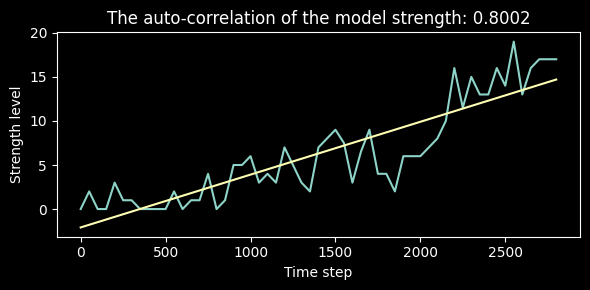

<Figure size 640x480 with 0 Axes>

In [11]:
# Difficulty Estimation

eval_checkpoint = 50
num_wins = 10
num_playouts = 1500

eval_df["batch"] = eval_df.index * eval_checkpoint
eval_df.set_index("batch", inplace=True)

eval_df["strength"] = (eval_df["win"] + eval_df["tie"] / 2 + (eval_df["numPlayouts"] / num_playouts  - 1) * num_wins).round(2)
eval_df["strength"] = eval_df["strength"].map(lambda x: 0 if x < 0 else x)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = eval_df.index.values.reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

fig, len_axes = plt.subplots(1, 1, figsize=(6, 3))

len_axes = eval_df["strength"].plot(ax=len_axes)
len_axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
len_axes.plot(x_axis, list(map(strength_estimator, x_axis)))
len_axes.set_xlabel('Time step')
len_axes.set_ylabel('Strength level')

plt.show()
plt.savefig("imgs/strength.png", dpi=300)

[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training
[Warn] The loss does not decrease significantly, which prevents the convergence of the model: -0.2944 > -0.5
[Warn] There might be a problem in loss function or hyperparameters


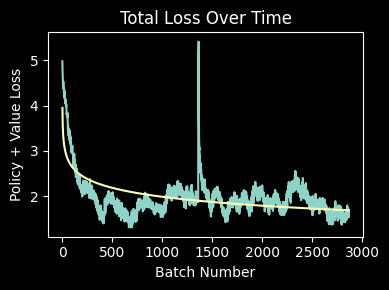

<Figure size 640x480 with 0 Axes>

In [12]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")

loss_significance = -.5

loss_corr = autocorr(train_df, "loss")

if loss_corr > loss_significance:
    print(f"[Warn] The loss does not decrease significantly, which prevents the convergence of the model: {loss_corr:.4f} > {loss_significance}")
    print(f"[Warn] There might be a problem in loss function or hyperparameters")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1
    
loss_lr = LinearRegression()
loss_lr.fit(np.log(x_axis), train_df["loss"])
loss_estimator = lambda x: loss_lr.coef_[0] * x + loss_lr.intercept_
    
fig, len_axes = plt.subplots(1, 1, figsize=(4, 3))
ax = train_df["loss"].plot(ax=len_axes)
ax.set_title("Total Loss Over Time")
ax.set_xlabel("Batch Number")
ax.set_ylabel("Policy + Value Loss")
ax.plot(x_axis, list(map(loss_estimator, np.log(x_axis))))

plt.show()
plt.savefig('imgs/loss.png', dpi=300)

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one
[Warn] Entropy seems to not decrease during training: -0.0060 > -0.5
[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive


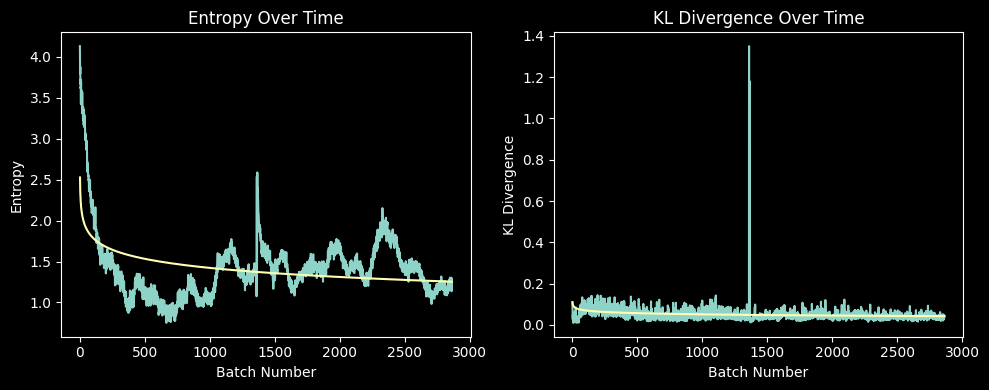

<Figure size 640x480 with 0 Axes>

In [13]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

entropy_significance = -.5
kl_significance = -0.01

entropy_corr = autocorr(train_df, "entropy")
kl_corr = autocorr(train_df, "kl")

if entropy_corr > entropy_significance:
    print(f"[Warn] Entropy seems to not decrease during training: {entropy_corr:.4f} > {entropy_significance}")
    print(f"[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive")

if kl_corr > kl_significance:
    print(f"[Warn] KL Divergence does not decrease over time as much as expected: {kl_corr:.4f} > {kl_significance}")
    print(f"[Warn] The model might still need more training or there might be other destabilizing factors causing this issue")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

entropy_lr = LinearRegression()
entropy_lr.fit(np.log(x_axis), train_df["entropy"].values)
entropy_estimator = lambda x: entropy_lr.coef_[0] * x + entropy_lr.intercept_

kl_lr = LinearRegression()
kl_lr.fit(np.log(x_axis), train_df["kl"])
kl_estimator = lambda x: kl_lr.coef_[0] * x + kl_lr.intercept_

fig, len_axes = plt.subplots(1, 2, figsize=(10, 4))
ax1 = train_df["entropy"].plot(ax=len_axes[0])
ax1.set_title("Entropy Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Entropy")
ax1.plot(x_axis, list(map(entropy_estimator, np.log(x_axis))))

ax2 = train_df["kl"].plot(ax=len_axes[1])
ax2.set_title("KL Divergence Over Time")
ax2.set_xlabel("Batch Number")
ax2.set_ylabel("KL Divergence")
ax2.plot(x_axis, list(map(kl_estimator, np.log(x_axis))))

plt.show()
plt.savefig('imgs/entropy_kl.png', dpi=300)

[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward


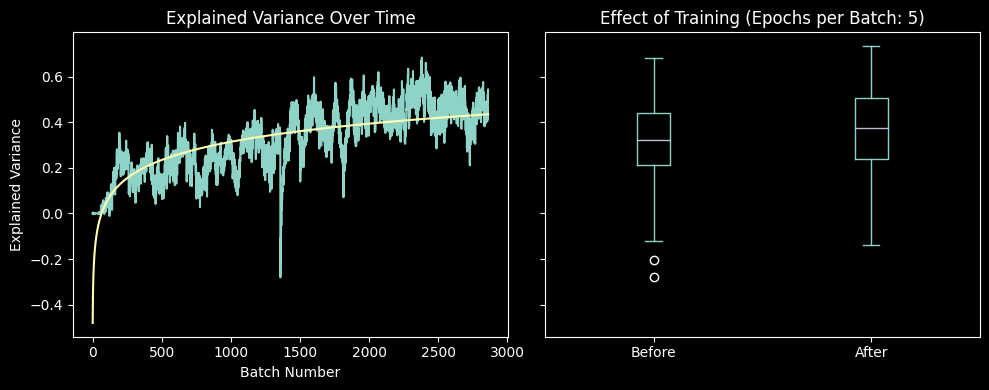

<Figure size 640x480 with 0 Axes>

In [14]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .4
expl_var_difference_significance = .01

expl_var_corr = autocorr(train_df, "explVarOld")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr:.4f} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

expl_var_difference = (train_df["explVarNew"] - train_df["explVarOld"]).mean()
if expl_var_difference < expl_var_difference_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {expl_var_difference:.4f} < {expl_var_difference_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

expl_var_lr = LinearRegression()
expl_var_lr.fit(np.log(x_axis), train_df["explVarOld"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, len_axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = train_df["explVarOld"].plot(ax=len_axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, np.log(x_axis))))

expl_var_difference_stats = train_df[["explVarOld", "explVarNew"]]
ax2 = expl_var_difference_stats.plot(kind="box", ax=len_axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_xticklabels(["Before", "After"])

plt.show()
plt.savefig('imgs/expl_var.png', dpi=300)
plt.close(fig)

In [15]:
from tqdm import tqdm
from src import Gomoku, Player, play_game

def competition(
    game: Gomoku,
    n_games: int,
    player1_args: tuple[str, Player, float], 
    player2_args: tuple[str, Player, float],
    bar: tqdm = None,
    *args, **kwargs
) -> pd.DataFrame:
    
    name1, player1, epsilon1 = player1_args
    name2, player2, epsilon2 = player2_args
    
    fst_time_stats, snd_time_stats = [], []
    
    results = []
    for _ in range(n_games):
        new_game, curr_started, timeline = play_game(game, player1, player2, epsilon1, epsilon2, *args, **kwargs)
        
        timeline += [np.nan] * (game.M*game.N - len(timeline))
        fst = pd.Series(timeline[0::2])
        snd = pd.Series(timeline[1::2])
        
        score = new_game.score()
        if not curr_started:
            score *= -1
            fst, snd = snd, fst
            
        fst_time_stats += [fst]
        snd_time_stats += [snd]
        
        results.append({
            "score": score, 
            "curr_started": curr_started, 
            "length": len(new_game.history),
        })
        
        if bar is not None:
            bar.update(1)
    
    results = pd.DataFrame(results)  
    fst_time_stats, snd_time_stats = pd.DataFrame(fst_time_stats), pd.DataFrame(snd_time_stats)  
    
    indices = [f"{name1}_started", f"{name2}_started"] # True, False
    columns = [f"{name1}_won", "Tie", f"{name2}_won"] # 1, 0, -1

    results_counts = pd.DataFrame(index=indices, columns=columns)
    results_lengths = results.copy()

    results_counts.fillna(0, inplace=True)

    for column in columns:
        for index in indices:
            index_val = True if index == f"{name1}_started" else False
            column_val = 1 if column == f"{name1}_won" else -1 if column == f"{name2}_won" else 0
            
            filter_fn = lambda x: (x["curr_started"] == index_val) & (x["score"] == column_val)
            
            results_lengths[index + '_' + column] = results_lengths.apply(lambda x: x["length"] if filter_fn(x) else np.nan, axis=1)
            results_counts.loc[index, column] = len(results[filter_fn(results)]) / n_games
    
    results_lengths.drop(["curr_started", "score", "length"], axis=1, inplace=True)
    
    return results_counts, results_lengths, fst_time_stats, snd_time_stats

def competition_results(
    game: Gomoku, 
    n_games: int, 
    player_i: tuple[str, Player, float], 
    player_j: tuple[str, Player, float],
    axes: tuple[tuple[plt.Axes, plt.Axes], tuple[plt.Axes, plt.Axes]],
    *args, **kwargs,
):
    
    results_counts, results_lengths, fst_time_stats, snd_time_stats = competition(
        game, 
        n_games, 
        player1_args=player_i,
        player2_args=player_j,
        *args, **kwargs,
    )
    
    [time_axes, len_axes] = axes
    
    sns.violinplot(data=results_lengths, ax=len_axes[0])
        
    len_axes[0].set_title(f"Expected Lengths (n = {n_games})")
    len_axes[0].set_ylabel("Length")
    len_axes[0].set_xlabel("Outcome")
    len_axes[0].set_xticklabels([])
    len_axes[0].legend(
        prop={'size': 8},
        loc="upper left", 
        fancybox=True,
        shadow=True,
        labels=results_lengths.columns,
    )
        
    sns.heatmap(results_counts, cmap="summer", annot=True, ax=len_axes[1])
    len_axes[1].set_title(f"Outcome Probs (n = {n_games})")
    
    fst_time_stats_notna = fst_time_stats.dropna(axis=1, how="all")
    sns.violinplot(data=fst_time_stats_notna, inner="quartile", ax=time_axes[0])
    time_axes[0].set_title(f"Timeline of {player_i[0]}")

    snd_time_stats_notna = snd_time_stats.dropna(axis=1, how="all")
    sns.violinplot(data=snd_time_stats_notna, inner="quartile", ax=time_axes[1])
    time_axes[1].set_title(f"Timeline of {player_j[0]}")
    
    return results_counts, results_lengths, fst_time_stats, snd_time_stats

In [25]:
game = Gomoku(*MEDIUM_GAME)
n_games = 10
players = all_players[1:]
tested_players = players[:2]

n_players = len(players)
n_tested_players = len(tested_players)

with tqdm(
    range((n_tested_players * (n_players - 1) - 1) * n_games), 
    desc="Competition",
    position=0,
    unit="game",
) as bar:
    for i in range(n_tested_players):
        tested_player = tested_players[i]
        for j in range(i + 1, n_players):
            rival_player = players[j]
            fig, axes = plt.subplots(2, 2, figsize=(10, 10))
            competition_results(game, n_games, tested_player, rival_player, axes, fairness=.5, timeline=True, bar=bar)
            plt.savefig(f"imgs/competition/{tested_player[0]}_{rival_player[0]}.png", dpi=300)
            plt.close(fig)

Competition: 100%|██████████| 70/70 [31:13<00:00, 26.77s/game]


## Game Is Solved For 6, 6, 4!

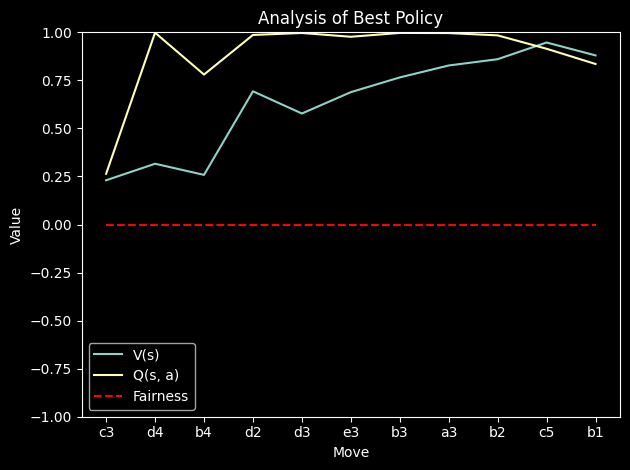

In [26]:
# Fairness of Game

from src import Gomoku, Deep_Player, Pattern

Pi_s = "c3,d4,b4,d2,d3,e3,b3,a3,b2,c5,b1" # winning strategy for the first player

V_s = []
Q_sa = []

net_player = Deep_Player(
    iterations=400, 
    policy_value_fn=small_net.policy_value_fn_sorted, 
    c_puct=5,
)

game = Gomoku(*SMALL_GAME)
for move in Pattern.loc_to_move(Pi_s):
    probs, value = small_net.policy_value_fn_sorted(game)
    max_prob, max_action = max(probs)
    assert max_action == move, "The best policy is different from the given move"
    game.play(move)
    V_s += [value.detach().item()]
    Q_sa += [max_prob]
    
x_axis = Pi_s.split(",")
ax = plt.subplot(1, 1, 1)
ax.plot(x_axis, V_s)
ax.plot(x_axis, Q_sa)
ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")
ax.set_ylim(-1, 1)
ax.set_xlabel("Move")
ax.set_ylabel("Value")
ax.set_title("Analysis of Best Policy")
ax.legend(["V(s)", "Q(s, a)", "Fairness"])
# plt.show()
plt.savefig("imgs/fairness_6_6_4.png", dpi=300)